Probe 1: intercept = -1.34 nA, slope = 9.54 nA/V (= 104.84 MΩ)
Probe 2: intercept = -35.28 nA, slope = 9.85 nA/V (= 101.52 MΩ)
Probe 3: intercept = -12.27 nA, slope = 9.51 nA/V (= 105.15 MΩ)
Probe 4: intercept = -14.16 nA, slope = 9.74 nA/V (= 102.62 MΩ)


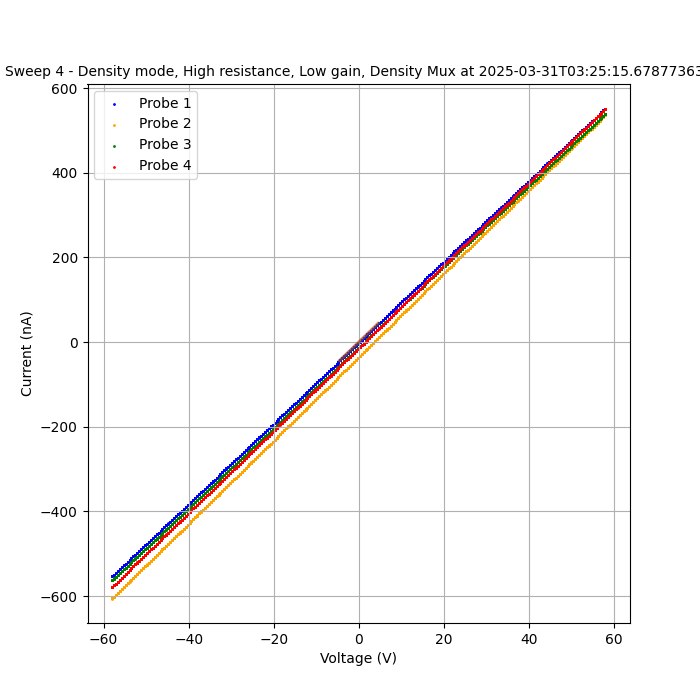

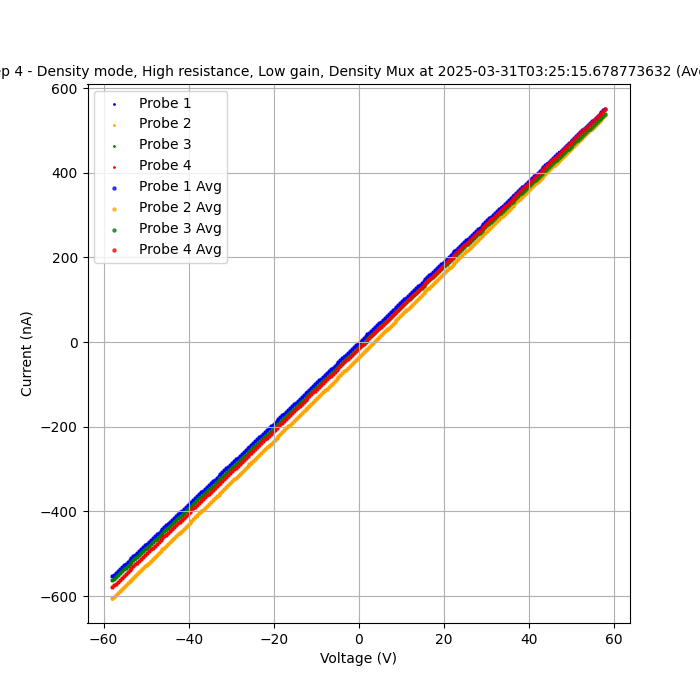

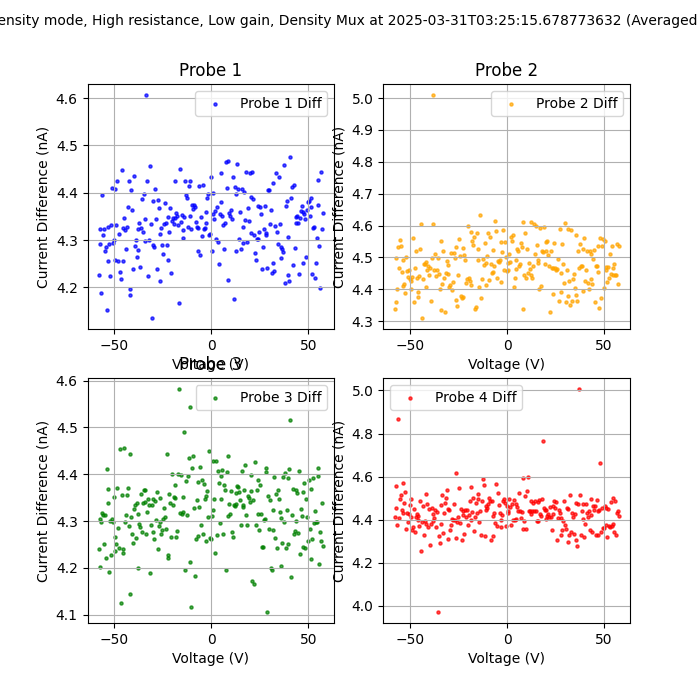

In [ ]:
%matplotlib widget

import cdflib
import numpy as np
import matplotlib.pyplot as plt

def filter_out_fill_values(lists, threshold=1e10):
    for list in lists:
        list[np.abs(list) > threshold] = np.nan
    return lists

def get_saturation_and_slope(x, y, saturation = True, percent=0.01):
        # Ignore NaNs
        valid = ~np.isnan(y)
        x_valid = x[valid]
        y_valid = y[valid]
        n = len(y_valid)

        if saturation:
            # Lower saturation window: start from first, count until >1% change
            lower_ref = y_valid[0]
            lower_window = 1
            for i in range(1, n):
                if np.abs(y_valid[i] - lower_ref) > percent * np.abs(lower_ref):
                    break
                lower_window += 1
            lower_sat = np.nanmean(y_valid[:lower_window])

            # Upper saturation window: start from last, count until >1% change
            upper_ref = y_valid[-1]
            upper_window = 1
            for i in range(1, n):
                if np.abs(y_valid[-(i+1)] - upper_ref) > percent * np.abs(upper_ref):
                    break
                upper_window += 1
            upper_sat = np.nanmean(y_valid[-upper_window:])

        else: # Only get the slope
            lower_window = 0
            upper_window = 0
            lower_sat = np.nan
            upper_sat = np.nan

        # Linear region: avoid saturation windows
        mid_start = lower_window
        mid_end = n - upper_window
        x_mid = x_valid[mid_start:mid_end]
        y_mid = y_valid[mid_start:mid_end]
        slope, intercept = np.polyfit(x_mid, y_mid, 1)

        return lower_sat, upper_sat, slope, intercept, x_mid, y_mid, lower_window, upper_window

def avg_offset_hysteresis(up_list, down_list, percent=0.8):
# Calculate average offset between up and down sweeps for each probe
    # Ignore NaNs
    valid_up = ~np.isnan(up_list)
    valid_down = ~np.isnan(down_list)
    up_list = up_list[valid_up]
    down_list = down_list[valid_down]
    start = int((1-percent)/2 * len(up_list))
    end = int((1+percent)/2 * len(up_list))
    up_list_center = up_list[start:end]
    down_list_center = down_list[start:end]
    offset = np.nanmean(up_list_center - down_list_center)
    return offset

def filter_nan_for_fit(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    return x[mask], y[mask]

def average_by_n(x, n):
    m = len(x) // n
    return np.mean(x[:m*n].reshape(-1, n), axis=1)

table3A = np.repeat(np.linspace(-58, 58, 256), 10)  # V
table3A = np.tile(table3A, 2)
table3B = np.repeat(np.linspace(58, -58, 256), 10)  # V
table3B = np.tile(table3B, 2)
table0A = np.repeat(np.linspace(-4.8, 4.8, 256), 10)  # V
table0A = np.tile(table0A, 2)
table2A = np.repeat(np.linspace(-0.5, 0.5, 256), 10)  # µA
table2A = np.tile(table2A, 2)
table2B = np.repeat(np.linspace(0.5, -0.5, 256), 10)  # µA
table2B = np.tile(table2B, 2)
tables = {'table3A': table3A, 'table3B': table3B, 'table0A': table0A, 'table2A': table2A, 'table2B': table2B}

colors = ['blue', 'orange', 'green', 'red']

sweep_info = [
    "Sweep 1 - Density mode, High resistance, High gain, Density Mux at ",
    "Sweep 2 - Density mode, Low resistance, Low gain, Density Mux at ",
    "Sweep 3 - Density mode, Low resistance, High gain, Density Mux at ",
    "Sweep 4 - Density mode, High resistance, Low gain, Density Mux at ",
    "Sweep 5 - Density mode, Low resistance, High gain, E-field Mux at ",
    "Sweep 7 - E-field mode, High resistance, Current bias, E-field Mux at ",
    "Sweep 8 - Open Probe, E-field mode, High resistance, Current bias, E-field Mux at ",
    "Sweep 9 - E-field mode, High resistance, Floating, E-field Mux at ",
    "Sweep 10 - E-field mode, Low resistance, Floating, E-field Mux at ",
    "Sweep 6 at ",
]

cdf_file = cdflib.CDF('../DATA/JUICE_L1a_RPWI-LP-SID2_SRVY_SWEEP_20250331T032129_V02.cdf')
epoch = cdf_file.varget('Epoch')
epoch = cdflib.cdfepoch.to_datetime(epoch)
lp_data = cdf_file.varget('LP_DATA_ENG')

# Sweep 1
if False:
    probe_1, probe_2, probe_3, probe_4 = filter_out_fill_values([lp_data[0,0,:], lp_data[1,1,:], lp_data[2,2,:], lp_data[3,3,:]], threshold=1e10)

    lower_sat_1, upper_sat_1, slope_1, intercept_1, x_mid_1, y_mid_1, lw1, uw1 = get_saturation_and_slope(tables['table3A'], probe_1)
    lower_sat_2, upper_sat_2, slope_2, intercept_2, x_mid_2, y_mid_2, lw2, uw2 = get_saturation_and_slope(tables['table3A'], probe_2)
    lower_sat_3, upper_sat_3, slope_3, intercept_3, x_mid_3, y_mid_3, lw3, uw3 = get_saturation_and_slope(tables['table3A'], probe_3)
    lower_sat_4, upper_sat_4, slope_4, intercept_4, x_mid_4, y_mid_4, lw4, uw4 = get_saturation_and_slope(tables['table3A'], probe_4)

    print(f"Probe 1: lower saturation = {lower_sat_1:.2f} nA (window= {lw1} points), upper saturation = {upper_sat_1:.2f} nA (window= {uw1} points), intercept = {intercept_1:.2f} nA, slope = {slope_1:.2f} nA/V (= {1e3/slope_1:.2f} MΩ)")
    print(f"Probe 2: lower saturation = {lower_sat_2:.2f} nA (window= {lw2} points), upper saturation = {upper_sat_2:.2f} nA (window= {uw2} points), intercept = {intercept_2:.2f} nA, slope = {slope_2:.2f} nA/V (= {1e3/slope_2:.2f} MΩ)")
    print(f"Probe 3: lower saturation = {lower_sat_3:.2f} nA (window= {lw3} points), upper saturation = {upper_sat_3:.2f} nA (window= {uw3} points), intercept = {intercept_3:.2f} nA, slope = {slope_3:.2f} nA/V (= {1e3/slope_3:.2f} MΩ)")
    print(f"Probe 4: lower saturation = {lower_sat_4:.2f} nA (window= {lw4} points), upper saturation = {upper_sat_4:.2f} nA (window= {uw4} points), intercept = {intercept_4:.2f} nA, slope = {slope_4:.2f} nA/V (= {1e3/slope_4:.2f} MΩ)")

    plt.figure(figsize=(7, 7))
    plt.title(sweep_info[0] + str(epoch[0]), fontsize=10)
    plt.scatter(tables['table3A'], probe_1, label='Probe 1', s=1, color=colors[0])
    plt.scatter(tables['table3A'], probe_2, label='Probe 2', s=1, color=colors[1])
    plt.scatter(tables['table3A'], probe_3, label='Probe 3', s=1, color=colors[2])
    plt.scatter(tables['table3A'], probe_4, label='Probe 4', s=1, color=colors[3])

    for i, (lower, upper, color) in enumerate([
        (lower_sat_1, upper_sat_1, colors[0]),
        (lower_sat_2, upper_sat_2, colors[1]),
        (lower_sat_3, upper_sat_3, colors[2]),
        (lower_sat_4, upper_sat_4, colors[3]),
    ]):
        plt.axhline(lower, color=color, linestyle='--', alpha=0.2)
        plt.axhline(upper, color=color, linestyle='--', alpha=0.2)

    for x_mid, y_mid, slope, color in [
        (x_mid_1, y_mid_1, slope_1, colors[0]),
        (x_mid_2, y_mid_2, slope_2, colors[1]),
        (x_mid_3, y_mid_3, slope_3, colors[2]),
        (x_mid_4, y_mid_4, slope_4, colors[3]),
    ]:
        intercept = np.nanmean(y_mid) - slope * np.nanmean(x_mid)
        x_fit = np.linspace(np.nanmin(x_mid), np.nanmax(x_mid), 100)
        y_fit = slope * x_fit + intercept
        plt.plot(x_fit, y_fit, color=color, alpha=0.3, linewidth=2)

    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()
    plt.show()

# Sweep 2
if False:
    probe_1_up, probe_1_down, probe_2_up, probe_2_down, probe_3_up, probe_3_down, probe_4_up, probe_4_down = filter_out_fill_values([lp_data[4,0,:], lp_data[5,0,:], lp_data[6,1,:], lp_data[7,1,:], lp_data[8,2,:], lp_data[9,2,:], lp_data[10,3,:], lp_data[11,3,:]], threshold=1e10)

    avg_diff_1 = avg_offset_hysteresis(probe_1_up, probe_1_down)
    avg_diff_2 = avg_offset_hysteresis(probe_2_up, probe_2_down)
    avg_diff_3 = avg_offset_hysteresis(probe_3_up, probe_3_down)
    avg_diff_4 = avg_offset_hysteresis(probe_4_up, probe_4_down)

    print(f"Probe 1 average difference: {avg_diff_1:.3f} nA")
    print(f"Probe 2 average difference: {avg_diff_2:.3f} nA")
    print(f"Probe 3 average difference: {avg_diff_3:.3f} nA")
    print(f"Probe 4 average difference: {avg_diff_4:.3f} nA")

    correction_1 = 0.87
    correction_2 = 0.84
    correction_3 = 1.09
    correction_4 = 1.07

    _, _, slope_1, intercept_1, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_1_up)
    _, _, slope_2, intercept_2, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_2_up)
    _, _, slope_3, intercept_3, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_3_up)
    _, _, slope_4, intercept_4, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_4_up)

    print(f"Probe 1: intercept = {intercept_1:.2f} nA, slope = {slope_1:.2f} nA/V (= {1e3/slope_1:.2f} MΩ)")
    print(f"Probe 2: intercept = {intercept_2:.2f} nA, slope = {slope_2:.2f} nA/V (= {1e3/slope_2:.2f} MΩ)")
    print(f"Probe 3: intercept = {intercept_3:.2f} nA, slope = {slope_3:.2f} nA/V (= {1e3/slope_3:.2f} MΩ)")
    print(f"Probe 4: intercept = {intercept_4:.2f} nA, slope = {slope_4:.2f} nA/V (= {1e3/slope_4:.2f} MΩ)")

    print("Probe 1 corrected slope: {:.2f} nA/V (= {:.2f} MΩ)".format(slope_1 + correction_1, 1e3 / (slope_1 + correction_1)))
    print("Probe 2 corrected slope: {:.2f} nA/V (= {:.2f} MΩ)".format(slope_2 + correction_2, 1e3 / (slope_2 + correction_2)))
    print("Probe 3 corrected slope: {:.2f} nA/V (= {:.2f} MΩ)".format(slope_3 + correction_3, 1e3 / (slope_3 + correction_3)))
    print("Probe 4 corrected slope: {:.2f} nA/V (= {:.2f} MΩ)".format(slope_4 + correction_4, 1e3 / (slope_4 + correction_4)))

    plt.figure(figsize=(7, 7))
    plt.suptitle(sweep_info[1] + str(epoch[4]), fontsize=10)
    
    plt.subplot(2, 2, 1)
    plt.title('Probe 1')
    plt.scatter(tables['table3A'], probe_1_up, label='Probe 1 Up', s=1, alpha=0.5)
    plt.scatter(tables['table3B'], probe_1_down, label='Probe 1 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 2)
    plt.title('Probe 2')
    plt.scatter(tables['table3A'], probe_2_up, label='Probe 2 Up', s=1, alpha=0.5)
    plt.scatter(tables['table3B'], probe_2_down, label='Probe 2 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 3)
    plt.title('Probe 3')
    plt.scatter(tables['table3A'], probe_3_up, label='Probe 3 Up', s=1, alpha=0.5)
    plt.scatter(tables['table3B'], probe_3_down, label='Probe 3 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 4)
    plt.title('Probe 4')
    plt.scatter(tables['table3A'], probe_4_up, label='Probe 4 Up', s=1, alpha=0.5)
    plt.scatter(tables['table3B'], probe_4_down, label='Probe 4 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    n = 10
    # For each probe, average every n points for the up sweep
    probe_1_up_avg = average_by_n(probe_1_up, n)
    probe_2_up_avg = average_by_n(probe_2_up, n)
    probe_3_up_avg = average_by_n(probe_3_up, n)
    probe_4_up_avg = average_by_n(probe_4_up, n)
    table3A_avg = average_by_n(tables['table3A'], n)

    plt.figure(figsize=(7, 7))
    plt.suptitle(sweep_info[1] + str(epoch[4]) + " (Averaged)", fontsize=10)

    plt.subplot(2, 2, 1)
    plt.title('Probe 1')
    plt.scatter(tables['table3A'], probe_1_up, label='Probe 1 Up', s=1)
    plt.scatter(table3A_avg, probe_1_up_avg, label='Avg', s=5, color=colors[0], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 2)
    plt.title('Probe 2')
    plt.scatter(tables['table3A'], probe_2_up, label='Probe 2 Up', s=1)
    plt.scatter(table3A_avg, probe_2_up_avg, label='Avg', s=5, color=colors[1], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 3)
    plt.title('Probe 3')
    plt.scatter(tables['table3A'], probe_3_up, label='Probe 3 Up', s=1)
    plt.scatter(table3A_avg, probe_3_up_avg, label='Avg', s=5, color=colors[2], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 4)
    plt.title('Probe 4')
    plt.scatter(tables['table3A'], probe_4_up, label='Probe 4 Up', s=1)
    plt.scatter(table3A_avg, probe_4_up_avg, label='Avg', s=5, color=colors[3], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

# Sweep 3
if False:
    probe_1, probe_2, probe_3, probe_4 = filter_out_fill_values([lp_data[12,0,:], lp_data[13,1,:], lp_data[14,2,:], lp_data[15,3,:]], threshold=1e10)

    lower_sat_1, upper_sat_1, slope_1, intercept_1, x_mid_1, y_mid_1, lw1, uw1 = get_saturation_and_slope(tables['table0A'], probe_1)
    lower_sat_2, upper_sat_2, slope_2, intercept_2, x_mid_2, y_mid_2, lw2, uw2 = get_saturation_and_slope(tables['table0A'], probe_2)
    lower_sat_3, upper_sat_3, slope_3, intercept_3, x_mid_3, y_mid_3, lw3, uw3 = get_saturation_and_slope(tables['table0A'], probe_3)
    lower_sat_4, upper_sat_4, slope_4, intercept_4, x_mid_4, y_mid_4, lw4, uw4 = get_saturation_and_slope(tables['table0A'], probe_4)

    print(f"Probe 1: lower saturation = {lower_sat_1:.2f} nA (window= {lw1} points), upper saturation = {upper_sat_1:.2f} nA (window= {uw1} points), intercept = {intercept_1:.2f} nA, slope = {slope_1:.2f} nA/V (= {1e3/slope_1:.2f} MΩ)")
    print(f"Probe 2: lower saturation = {lower_sat_2:.2f} nA (window= {lw2} points), upper saturation = {upper_sat_2:.2f} nA (window= {uw2} points), intercept = {intercept_2:.2f} nA, slope = {slope_2:.2f} nA/V (= {1e3/slope_2:.2f} MΩ)")
    print(f"Probe 3: lower saturation = {lower_sat_3:.2f} nA (window= {lw3} points), upper saturation = {upper_sat_3:.2f} nA (window= {uw3} points), intercept = {intercept_3:.2f} nA, slope = {slope_3:.2f} nA/V (= {1e3/slope_3:.2f} MΩ)")
    print(f"Probe 4: lower saturation = {lower_sat_4:.2f} nA (window= {lw4} points), upper saturation = {upper_sat_4:.2f} nA (window= {uw4} points), intercept = {intercept_4:.2f} nA, slope = {slope_4:.2f} nA/V (= {1e3/slope_4:.2f} MΩ)")

    colors = ['blue', 'orange', 'green', 'red']

    plt.figure(figsize=(7, 7))
    plt.title(sweep_info[2] + str(epoch[12]), fontsize=10)
    plt.scatter(tables['table0A'], probe_1, label='Probe 1', s=1, color=colors[0])
    plt.scatter(tables['table0A'], probe_2, label='Probe 2', s=1, color=colors[1])
    plt.scatter(tables['table0A'], probe_3, label='Probe 3', s=1, color=colors[2])
    plt.scatter(tables['table0A'], probe_4, label='Probe 4', s=1, color=colors[3])

    for i, (lower, upper, color) in enumerate([
        (lower_sat_1, upper_sat_1, colors[0]),
        (lower_sat_2, upper_sat_2, colors[1]),
        (lower_sat_3, upper_sat_3, colors[2]),
        (lower_sat_4, upper_sat_4, colors[3]),
    ]):
        plt.axhline(lower, color=color, linestyle='--', alpha=0.2)
        plt.axhline(upper, color=color, linestyle='--', alpha=0.2)

    for x_mid, y_mid, slope, color in [
        (x_mid_1, y_mid_1, slope_1, colors[0]),
        (x_mid_2, y_mid_2, slope_2, colors[1]),
        (x_mid_3, y_mid_3, slope_3, colors[2]),
        (x_mid_4, y_mid_4, slope_4, colors[3]),
    ]:
        intercept = np.nanmean(y_mid) - slope * np.nanmean(x_mid)
        x_fit = np.linspace(np.nanmin(x_mid), np.nanmax(x_mid), 100)
        y_fit = slope * x_fit + intercept
        plt.plot(x_fit, y_fit, color=color, alpha=0.3, linewidth=2)

    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()
    plt.show()

# Sweep 4
if True:
    probe_1, probe_2, probe_3, probe_4 = filter_out_fill_values([lp_data[16,0,:], lp_data[17,1,:], lp_data[18,2,:], lp_data[19,3,:]], threshold=1e10)

    _, _, slope_1, intercept_1, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_1)
    _, _, slope_2, intercept_2, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_2)
    _, _, slope_3, intercept_3, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_3)
    _, _, slope_4, intercept_4, _, _, _, _ = get_saturation_and_slope(tables['table3A'], probe_4)

    print(f"Probe 1: intercept = {intercept_1:.2f} nA, slope = {slope_1:.2f} nA/V (= {1e3/slope_1:.2f} MΩ)")
    print(f"Probe 2: intercept = {intercept_2:.2f} nA, slope = {slope_2:.2f} nA/V (= {1e3/slope_2:.2f} MΩ)")
    print(f"Probe 3: intercept = {intercept_3:.2f} nA, slope = {slope_3:.2f} nA/V (= {1e3/slope_3:.2f} MΩ)")
    print(f"Probe 4: intercept = {intercept_4:.2f} nA, slope = {slope_4:.2f} nA/V (= {1e3/slope_4:.2f} MΩ)")

    n = 10
    # For each probe, average every n points for the up sweep
    probe_1_avg = average_by_n(probe_1, n)
    probe_2_avg = average_by_n(probe_2, n)
    probe_3_avg = average_by_n(probe_3, n)
    probe_4_avg = average_by_n(probe_4, n)
    table3A_avg = average_by_n(tables['table3A'], n)

    colors = ['blue', 'orange', 'green', 'red']

    plt.figure(figsize=(7, 7))
    plt.title(sweep_info[3] + str(epoch[16]), fontsize=10)
    plt.scatter(tables['table3A'], probe_1, label='Probe 1', s=1, color=colors[0])
    plt.scatter(tables['table3A'], probe_2, label='Probe 2', s=1, color=colors[1])
    plt.scatter(tables['table3A'], probe_3, label='Probe 3', s=1, color=colors[2])
    plt.scatter(tables['table3A'], probe_4, label='Probe 4', s=1, color=colors[3])

    for x_mid, y_mid, slope, color in [
        (x_mid_1, y_mid_1, slope_1, colors[0]),
        (x_mid_2, y_mid_2, slope_2, colors[1]),
        (x_mid_3, y_mid_3, slope_3, colors[2]),
        (x_mid_4, y_mid_4, slope_4, colors[3]),
    ]:
        intercept = np.nanmean(y_mid) - slope * np.nanmean(x_mid)
        x_fit = np.linspace(np.nanmin(x_mid), np.nanmax(x_mid), 100)
        y_fit = slope * x_fit + intercept
        plt.plot(x_fit, y_fit, color=color, alpha=0.3, linewidth=2)

    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(7, 7))
    plt.title(sweep_info[3] + str(epoch[16]) + " (Averaged)", fontsize=10)
    plt.scatter(tables['table3A'], probe_1, label='Probe 1', s=1, color=colors[0])
    plt.scatter(tables['table3A'], probe_2, label='Probe 2', s=1, color=colors[1])
    plt.scatter(tables['table3A'], probe_3, label='Probe 3', s=1, color=colors[2])
    plt.scatter(tables['table3A'], probe_4, label='Probe 4', s=1, color=colors[3])
    plt.scatter(table3A_avg, probe_1_avg, label='Probe 1 Avg', s=5, color=colors[0], alpha=0.7)
    plt.scatter(table3A_avg, probe_2_avg, label='Probe 2 Avg', s=5, color=colors[1], alpha=0.7)
    plt.scatter(table3A_avg, probe_3_avg, label='Probe 3 Avg', s=5, color=colors[2], alpha=0.7)
    plt.scatter(table3A_avg, probe_4_avg, label='Probe 4 Avg', s=5, color=colors[3], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (nA)')
    plt.legend()
    plt.grid()
    plt.show()

    diff_1 = np.diff(probe_1_avg)
    diff_2 = np.diff(probe_2_avg)
    diff_3 = np.diff(probe_3_avg)
    diff_4 = np.diff(probe_4_avg)

    plt.figure(figsize=(7, 7))
    plt.suptitle(sweep_info[3] + str(epoch[16]) + " (Averaged Differences)", fontsize=10)

    plt.subplot(2, 2, 1)
    plt.title('Probe 1')
    plt.scatter(table3A_avg[:-1], diff_1, label='Probe 1 Diff', s=5, color=colors[0], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current Difference (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 2)
    plt.title('Probe 2')
    plt.scatter(table3A_avg[:-1], diff_2, label='Probe 2 Diff', s=5, color=colors[1], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current Difference (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 3)
    plt.title('Probe 3')
    plt.scatter(table3A_avg[:-1], diff_3, label='Probe 3 Diff', s=5, color=colors[2], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current Difference (nA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 4)
    plt.scatter(table3A_avg[:-1], diff_4, label='Probe 4 Diff', s=5, color=colors[3], alpha=0.7)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current Difference (nA)')
    plt.legend()
    plt.grid()
    
    plt.show()

# Sweep 5
if False:
    probe_1, probe_2, probe_3, probe_4 = filter_out_fill_values([lp_data[20,0,:], lp_data[21,1,:], lp_data[22,2,:], lp_data[23,3,:]], threshold=1e10)

    # Remove NaN values before interpolation for each probe
    x1, y1 = filter_nan_for_fit(tables['table3A'], probe_1)
    x2, y2 = filter_nan_for_fit(tables['table3A'], probe_2)
    x3, y3 = filter_nan_for_fit(tables['table3A'], probe_3)
    x4, y4 = filter_nan_for_fit(tables['table3A'], probe_4)

    # Quadratic interpolation for each probe
    coeffs_1 = np.polyfit(x1, y1, 2)
    coeffs_2 = np.polyfit(x2, y2, 2)
    coeffs_3 = np.polyfit(x3, y3, 2)
    coeffs_4 = np.polyfit(x4, y4, 2)

    x_fit = np.linspace(np.nanmin(tables['table3A']), np.nanmax(tables['table3A']), 200)
    y_fit_1 = np.polyval(coeffs_1, x_fit)
    y_fit_2 = np.polyval(coeffs_2, x_fit)
    y_fit_3 = np.polyval(coeffs_3, x_fit)
    y_fit_4 = np.polyval(coeffs_4, x_fit)

    colors = ['blue', 'orange', 'green', 'red']

    print("Quadratic coefficients for Probe 1:", coeffs_1)
    print("Quadratic coefficients for Probe 2:", coeffs_2)
    print("Quadratic coefficients for Probe 3:", coeffs_3)
    print("Quadratic coefficients for Probe 4:", coeffs_4)

    plt.figure(figsize=(10, 8))
    plt.suptitle(sweep_info[4] + str(epoch[20]), fontsize=10)

    plt.subplot(2, 2, 1)
    plt.title('Probe 1')
    plt.scatter(tables['table3A'], probe_1, label='Probe 1', s=1, color=colors[0])
    plt.plot(x_fit, y_fit_1, color=colors[0], alpha=0.7, linewidth=2, label='Quadratic')
    plt.xlabel('Voltage (V)')
    plt.ylabel('Voltage (TM Units)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 2)
    plt.title('Probe 2')
    plt.scatter(tables['table3A'], probe_2, label='Probe 2', s=1, color=colors[1])
    plt.plot(x_fit, y_fit_2, color=colors[1], alpha=0.7, linewidth=2, label='Quadratic')
    plt.xlabel('Voltage (V)')
    plt.ylabel('Voltage (TM Units)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 3)
    plt.title('Probe 3')
    plt.scatter(tables['table3A'], probe_3, label='Probe 3', s=1, color=colors[2])
    plt.plot(x_fit, y_fit_3, color=colors[2], alpha=0.7, linewidth=2, label='Quadratic')
    plt.xlabel('Voltage (V)')
    plt.ylabel('Voltage (TM Units)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 4)
    plt.title('Probe 4')
    plt.scatter(tables['table3A'], probe_4, label='Probe 4', s=1, color=colors[3])
    plt.plot(x_fit, y_fit_4, color=colors[3], alpha=0.7, linewidth=2, label='Quadratic')
    plt.xlabel('Voltage (V)')
    plt.ylabel('Voltage (TM Units)')
    plt.legend()
    plt.grid()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    plt.figure(figsize=(7, 7))
    plt.title(sweep_info[4] + str(epoch[20]), fontsize=10)
    plt.scatter(tables['table3A'], probe_1, label='Probe 1', s=1, color=colors[0])
    plt.scatter(tables['table3A'], probe_2, label='Probe 2', s=1, color=colors[1])
    plt.scatter(tables['table3A'], probe_3, label='Probe 3', s=1, color=colors[2])
    plt.scatter(tables['table3A'], probe_4, label='Probe 4', s=1, color=colors[3])
    plt.xlabel('Voltage (V)')
    plt.ylabel('Voltage (TM Units)')
    plt.legend()
    plt.grid()
    plt.show()

# Sweep 7
if False:
    probe_1_up, probe_1_down, probe_2_up, probe_2_down, probe_3_up, probe_3_down, probe_4_up, probe_4_down = filter_out_fill_values([lp_data[24,0,:], lp_data[25,0,:], lp_data[26,1,:], lp_data[27,1,:], lp_data[28,2,:], lp_data[29,2,:], lp_data[30,3,:], lp_data[31,3,:]], threshold=1e10)

    avg_diff_1 = avg_offset_hysteresis(probe_1_up, probe_1_down, percent=1.0)
    avg_diff_2 = avg_offset_hysteresis(probe_2_up, probe_2_down, percent=1.0)
    avg_diff_3 = avg_offset_hysteresis(probe_3_up, probe_3_down, percent=1.0)
    avg_diff_4 = avg_offset_hysteresis(probe_4_up, probe_4_down, percent=1.0)

    print(f"Probe 1 average difference: {avg_diff_1:.3f} V")
    print(f"Probe 2 average difference: {avg_diff_2:.3f} V")
    print(f"Probe 3 average difference: {avg_diff_3:.3f} V")
    print(f"Probe 4 average difference: {avg_diff_4:.3f} V")

    plt.figure(figsize=(7, 7))
    plt.suptitle(sweep_info[5] + str(epoch[24]), fontsize=10)

    plt.subplot(2, 2, 1)
    plt.title('Probe 1')
    plt.scatter(probe_1_up, tables['table2A'], label='Probe 1 Up', s=1, alpha=0.5)
    plt.scatter(probe_1_down, tables['table2B'], label='Probe 1 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 2)
    plt.title('Probe 2')
    plt.scatter(probe_2_up, tables['table2A'], label='Probe 2 Up', s=1, alpha=0.5)
    plt.scatter(probe_2_down, tables['table2B'], label='Probe 2 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 3)
    plt.title('Probe 3')
    plt.scatter(probe_3_up, tables['table2A'], label='Probe 3 Up', s=1, alpha=0.5)
    plt.scatter(probe_3_down, tables['table2B'], label='Probe 3 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.legend()
    plt.grid()

    plt.subplot(2, 2, 4)
    plt.title('Probe 4')
    plt.scatter(probe_4_up, tables['table2A'], label='Probe 4 Up', s=1, alpha=0.5)
    plt.scatter(probe_4_down, tables['table2B'], label='Probe 4 Down', s=1, alpha=0.5)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

# Sweep 8
if False:
    probe_1, probe_2, probe_3, probe_4 = filter_out_fill_values([lp_data[32,0,:], lp_data[33,1,:], lp_data[34,2,:], lp_data[35,3,:]], threshold=1e10)

    plt.figure(figsize=(7, 7))
    plt.title(sweep_info[6] + str(epoch[32]), fontsize=10)
    plt.scatter(probe_1, tables['table2A'], label='Probe 1', s=1)
    plt.scatter(probe_2, tables['table2A'], label='Probe 2', s=1)
    plt.scatter(probe_3, tables['table2A'], label='Probe 3', s=1)
    plt.scatter(probe_4, tables['table2A'], label='Probe 4', s=1)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.legend()
    plt.grid()
    plt.show()

# Sweep 9
if False:
    probe_1, probe_2, probe_3, probe_4 = filter_out_fill_values([lp_data[36,0,:], lp_data[37,1,:], lp_data[38,2,:], lp_data[39,3,:]], threshold=1e10)

    _, _, slope_1, intercept_1, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_1, saturation = False)
    _, _, slope_2, intercept_2, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_2, saturation = False)
    _, _, slope_3, intercept_3, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_3, saturation = False)
    _, _, slope_4, intercept_4, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_4, saturation = False)

    print(f"Probe 1: intercept = {intercept_1:.2f} µA, slope = {slope_1:.5f}")
    print(f"Probe 2: intercept = {intercept_2:.2f} µA, slope = {slope_2:.5f}")
    print(f"Probe 3: intercept = {intercept_3:.2f} µA, slope = {slope_3:.5f}")
    print(f"Probe 4: intercept = {intercept_4:.2f} µA, slope = {slope_4:.5f}")

    plt.figure(figsize=(7, 7))
    plt.suptitle(sweep_info[7] + str(epoch[36]), fontsize=10)

    plt.subplot(2,2,1)
    plt.scatter(tables['table2A'], probe_1, s=1)
    x_fit_1 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_1 = slope_1 * x_fit_1 + intercept_1
    plt.plot(x_fit_1, y_fit_1, color='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 1')
    plt.grid()

    plt.subplot(2,2,2)
    plt.scatter(tables['table2A'], probe_2, s=1)
    x_fit_2 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_2 = slope_2 * x_fit_2 + intercept_2
    plt.plot(x_fit_2, y_fit_2, color ='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 2')
    plt.grid()

    plt.subplot(2,2,3)
    plt.scatter(tables['table2A'], probe_3, s=1)
    x_fit_3 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_3 = slope_3 * x_fit_3 + intercept_3
    plt.plot(x_fit_3, y_fit_3, color ='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 3')
    plt.grid()

    plt.subplot(2,2,4)
    plt.scatter(tables['table2A'], probe_4, s=1)
    x_fit_4 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_4 = slope_4 * x_fit_4 + intercept_4
    plt.plot(x_fit_4, y_fit_4, color ='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 4')
    plt.grid()

    plt.tight_layout()
    plt.show()

# Sweep 10
if False:
    probe_1, probe_2, probe_3, probe_4 = filter_out_fill_values([lp_data[40,0,:], lp_data[41,1,:], lp_data[42,2,:], lp_data[43,3,:]], threshold=1e10)

    _, _, slope_1, intercept_1, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_1, saturation = False)
    _, _, slope_2, intercept_2, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_2, saturation = False)
    _, _, slope_3, intercept_3, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_3, saturation = False)
    _, _, slope_4, intercept_4, _, _, _, _ = get_saturation_and_slope(tables['table2A'], probe_4, saturation = False)

    print(f"Probe 1: intercept = {intercept_1:.2f} µA, slope = {slope_1:.5f}")
    print(f"Probe 2: intercept = {intercept_2:.2f} µA, slope = {slope_2:.5f}")
    print(f"Probe 3: intercept = {intercept_3:.2f} µA, slope = {slope_3:.5f}")
    print(f"Probe 4: intercept = {intercept_4:.2f} µA, slope = {slope_4:.5f}")

    plt.figure(figsize=(7, 7))
    plt.suptitle(sweep_info[8] + str(epoch[40]), fontsize=10)

    plt.subplot(2,2,1)
    plt.scatter(tables['table2A'], probe_1, s=1)
    x_fit_1 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_1 = slope_1 * x_fit_1 + intercept_1
    plt.plot(x_fit_1, y_fit_1, color='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 1')
    plt.grid()

    plt.subplot(2,2,2)
    plt.scatter(tables['table2A'], probe_2, s=1)
    x_fit_2 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_2 = slope_2 * x_fit_2 + intercept_2
    plt.plot(x_fit_2, y_fit_2, color ='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 2')
    plt.grid()

    plt.subplot(2,2,3)
    plt.scatter(tables['table2A'], probe_3, s=1)
    x_fit_3 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_3 = slope_3 * x_fit_3 + intercept_3
    plt.plot(x_fit_3, y_fit_3, color ='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 3')
    plt.grid()

    plt.subplot(2,2,4)
    plt.scatter(tables['table2A'], probe_4, s=1)
    x_fit_4 = np.linspace(min(tables['table2A']), max(tables['table2A']), 100)
    y_fit_4 = slope_4 * x_fit_4 + intercept_4
    plt.plot(x_fit_4, y_fit_4, color ='r', alpha=0.3, linewidth=2)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (µA)')
    plt.title('Probe 4')
    plt.grid()

    plt.tight_layout()
    plt.show()